# Exercise 6

In [40]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

## Part 1

In [41]:
#Parameters
m = 10
mean_serviceT = 8
mean_interArrivalT = 1
n_repetitions = 10
n_customers = 10000

A = mean_interArrivalT * mean_serviceT

In [ ]:
def g1(i):
    return (A**i)/math.factorial(i)

def h1(x, m):
    choice =  np.random.uniform(0,1)
    choice =  choice < 0.5 
    if (x == 0):
        if choice:
            return 0
        else:
            return 1
        
    elif (x == m):
        if choice:
            return m
        else:
            return m-1
    
    else:
        if choice:
            return x-1
        else:
            return x+1

def a1(x,y):
    result = min(1,g1(y)/g1(x))
    return result

def genSamp(sample_size,start_value,burn_in,m):
    x = start_value
    result = []
    
    for _ in range(burn_in):
        y = h1(x,m)
        accept_rate = a1(x,y)
        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            x = y


    for _ in range(sample_size):
        y = h1(x,m)
        accept_rate = a1(x,y)
        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            result.append(y)
            x = y
        else:
            result.append(x)

    return result

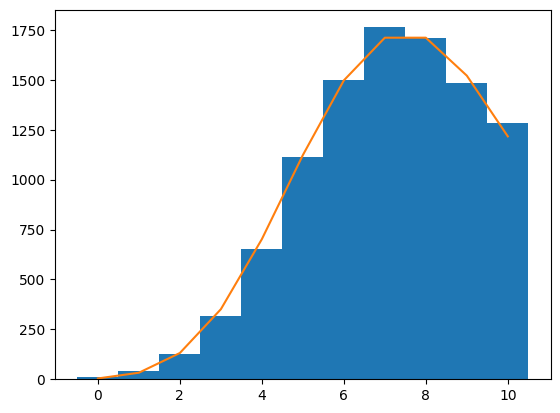

chi2: 0.013510583122751885


In [43]:
sample_size = 10000
start_value = 0
burn_in = int(sample_size/2)

data = np.array(genSamp(sample_size,start_value,burn_in,m))

observed,buckets,_ = plt.hist(data,bins=[-0.5+i for i in range(0,m+2)])

p = np.array([g1(i) for i in range(0,m+1)])

p_norm = p/p.sum()

expected = sample_size*p_norm

plt.plot(expected)
plt.show()

T = 0
for i in range(len(expected)):
    T += (observed[i]-expected[i])**2/expected[i]

chi2 = 1-stats.chi2.cdf(T,len(observed)-1)
print("chi2:",chi2)


## Part 2

In [44]:
A_1 = A_2 = 4
m = 10

### a)

In [ ]:
def g2(i,j):
    return (A_1**i/math.factorial(i)) * (A_2**j/math.factorial(j))

def h2(x,y,m):
    i_choices = [x for x in range(m+1)]
    j_choices = [x for x in range(m+1)]

    i_choices.remove(x)
    j_choices.remove(y)

    choice  = np.random.uniform(0,1)
    i_first = 0,5 > choice

    if i_first:
            i = int(np.random.uniform(0,m+1))

            j = int(np.random.uniform(0,m+1-i))

    else:
            j = int(np.random.uniform(0,m+1))

            i = int(np.random.uniform(0,(m+1-j)))
                
    return i,j

def a2(i_prev,j_prev,i_new,j_new):
    result = min(1,g2(i_new,j_new)/g2(i_prev,j_prev))
    return result

def genSamp_direct(sample_size,start_value_i,start_value_j,burn_in,m):
    cur_i = start_value_i
    cur_j = start_value_j

    result = []
    
    for _ in range(burn_in):
        new_i,new_j = h2(cur_i,cur_j,m)

        accept_rate = a2(cur_i,cur_j,new_i,new_j)

        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            cur_i = new_i
            cur_j = new_j

    for _ in range(sample_size):
        new_i,new_j = h2(cur_i,cur_j,m)

        accept_rate = a2(cur_i,cur_j,new_i,new_j)

        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            result.append((new_i,new_j))
            cur_i = new_i
            cur_j = new_j

        else:
            result.append((cur_i,cur_j))

    return result

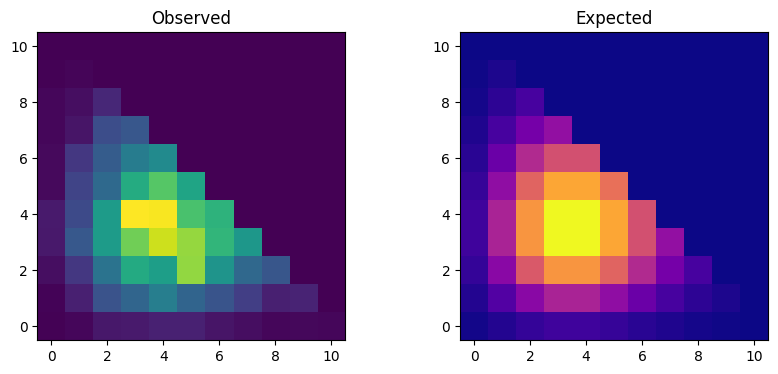

chi2: 0.0


In [103]:
sample_size = 10000
start_value_i = 0
start_value_j = 0
burn_in = int(sample_size/2)

data_direct = np.array(genSamp_direct(sample_size,start_value_i,start_value_j,burn_in,m))

observed,_,_ = np.histogram2d(data_direct[:,0],data_direct[:,1],bins=[np.arange(-0.5, m+1.5, 1),np.arange(-0.5, m+1.5, 1)])

p = np.zeros((m+1,m+1))

for i in range(m+1):
    for j in range(m+1-i):
        p[i,j] = g2(i,j)

p_norm = p/p.sum()

expected = sample_size*p_norm

#Plot together:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(observed.T, origin='lower', cmap='viridis')
ax[0].set_title("Observed")

ax[1].imshow(expected.T, origin='lower', cmap='plasma')
ax[1].set_title("Expected")

plt.show()

T = 0
for i in range(m+1):
    for j in range(m+1-i):
        if expected[i,j] > 0:
            T += (observed[i,j]-expected[i,j])**2/expected[i,j]

chi2 = 1-stats.chi2.cdf(T,(m+1)*(m+2)//2 - 1)
print("chi2:",chi2)

### b)

In [106]:
def h3(changed_cord,unchanged_cord,m):
    choice =  np.random.uniform(0,1)
    choice =  choice < 0.5 

    if (changed_cord == 0):
        if choice:
            return changed_cord
        else:
            return changed_cord+1

    elif (changed_cord+unchanged_cord == m):
        if choice:
            return changed_cord
        else:
            return changed_cord-1
        
    else:
        if choice:
            return changed_cord-1
        else:
            return changed_cord+1

def genSamp_coordinate(sample_size,start_value_i,start_value_j,burn_in,m):
    cur_i = start_value_i
    cur_j = start_value_j

    result = []
    
    for _ in range(burn_in):
        new_i= h3(cur_i,cur_j,m)

        accept_rate = a2(cur_i,cur_j,new_i,cur_j)

        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            cur_i = new_i

        new_j= h3(cur_j,cur_i,m)
        accept_rate = a2(cur_i,cur_j,cur_i,new_j)

        choice = np.random.uniform(0,1)
        if choice <= accept_rate:
            cur_j = new_j

    for _ in range(sample_size):
        new_i= h3(cur_i,cur_j,m)

        accept_rate = a2(cur_i,cur_j,new_i,cur_j)

        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            cur_i = new_i

        new_j= h3(cur_j,cur_i,m)
        accept_rate = a2(cur_i,cur_j,cur_i,new_j)

        choice = np.random.uniform(0,1)
        if choice <= accept_rate:
            cur_j = new_j

        result.append((cur_i,cur_j))

    return result

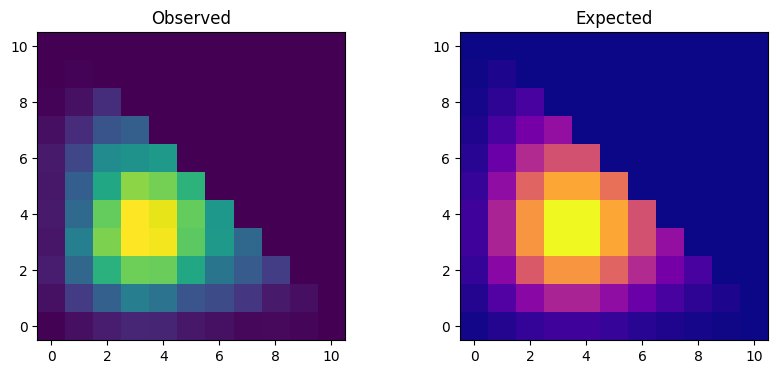

chi2: 0.0001262260580630059


In [107]:
sample_size = 10000
start_value_i = 0
start_value_j = 0
burn_in = int(sample_size/2)

data_coordinate = np.array(genSamp_coordinate(sample_size,start_value_i,start_value_j,burn_in,m))

observed,_,_ = np.histogram2d(data_coordinate[:,0],data_coordinate[:,1],bins=[np.arange(-0.5, m+1.5, 1),np.arange(-0.5, m+1.5, 1)])

p = np.zeros((m+1,m+1))

for i in range(m+1):
    for j in range(m+1-i):
        p[i,j] = g2(i,j)

p_norm = p/p.sum()

expected = sample_size*p_norm

#Plot together:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(observed.T, origin='lower', cmap='viridis')
ax[0].set_title("Observed")

ax[1].imshow(expected.T, origin='lower', cmap='plasma')
ax[1].set_title("Expected")

plt.show()

T = 0
for i in range(m+1):
    for j in range(m+1-i):
        if expected[i,j] > 0:
            T += (observed[i,j]-expected[i,j])**2/expected[i,j]

chi2 = 1-stats.chi2.cdf(T,(m+1)*(m+2)//2 - 1)
print("chi2:",chi2)

### c)

In [111]:
def hGibbs(x,y,m):
        i = int(np.random.uniform(0,m+1-y))
        return i

def genSamp_Gibbs(sample_size,start_value_i,start_value_j,burn_in,m):
    i = start_value_i
    j = start_value_j

    result = []
    for _ in range(burn_in):
        i = hGibbs(i,j,m)
        j = hGibbs(j,i,m)

    for _ in range(sample_size):
        i = hGibbs(i,j,m)
        j = hGibbs(j,i,m)
        result.append((i,j))

    return result

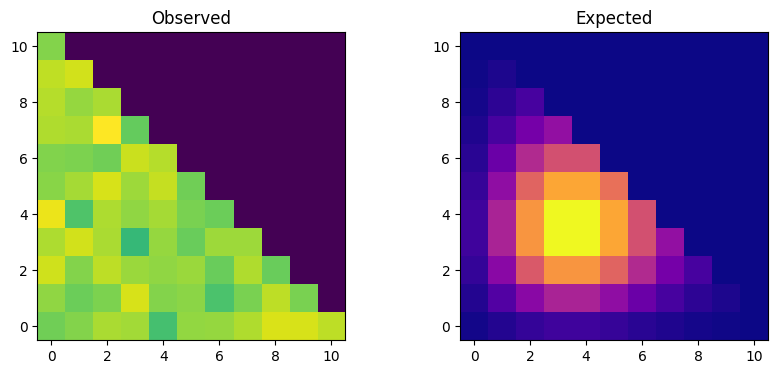

chi2: 0.0


In [112]:
sample_size = 10000
start_value_i = 0
start_value_j = 0
burn_in = int(sample_size/2)

data_Gibbs = np.array(genSamp_Gibbs(sample_size,start_value_i,start_value_j,burn_in,m))

observed,_,_ = np.histogram2d(data_Gibbs[:,0],data_Gibbs[:,1],bins=[np.arange(-0.5, m+1.5, 1),np.arange(-0.5, m+1.5, 1)])

p = np.zeros((m+1,m+1))

for i in range(m+1):
    for j in range(m+1-i):
        p[i,j] = g2(i,j)

p_norm = p/p.sum()

expected = sample_size*p_norm

#Plot together:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(observed.T, origin='lower', cmap='viridis')
ax[0].set_title("Observed")

ax[1].imshow(expected.T, origin='lower', cmap='plasma')
ax[1].set_title("Expected")

plt.show()

T = 0
for i in range(m+1):
    for j in range(m+1-i):
        if expected[i,j] > 0:
            T += (observed[i,j]-expected[i,j])**2/expected[i,j]

chi2 = 1-stats.chi2.cdf(T,(m+1)*(m+2)//2 - 1)
print("chi2:",chi2)

## Part 3

See others